<a href="https://colab.research.google.com/github/hamdikhasawneh/AI-sepsis/blob/main/notebooks/03_qsofa_baseline_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
#This will:
# 1. prepare hourly GCS
# 2. merge GCS into vitals
# 3. compute hourly qSOFA
# 4. summarize qSOFA into stay-level features
# 5. build a pure rule-based clinical qSOFA model
# 6. build an interpretable logistic regression model using qSOFA features
# 7. evaluate both on 6h / 12h / 24h

In [17]:
# ── 0. Mount Drive & imports ─────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/gp')  # adjust if feature_engineering.py is elsewhere

import numpy as np
import pandas as pd
from pathlib import Path

try:
    from feature_engineering import (
    FEATURE_COLS,
    compute_temporal_features,
    compute_sofa_features,
    compute_static_features,
    compute_missingness_features,
    compute_lab_features,
    build_feature_table,
    impute_with_medians,
    assert_no_leakage,
)
    print("feature_engineering module loaded ✓")
except ImportError:
    print("WARNING: feature_engineering.py not found — helpers not loaded.")

# ── 1. Paths ──────────────────────────────────────────────────────────────────
OUTPUT_DIR = Path('/content/drive/MyDrive/mimic_iv_processed')

# ── 2. Load all file 2 outputs ────────────────────────────────────────────────
print("Loading file 2 outputs...")

# Static feature table
all_features = pd.read_csv(OUTPUT_DIR / 'engineered_features.csv')
print(f"Features      : {all_features.shape}")

# Labels (hourly, rolling)
hourly_labels = pd.read_csv(OUTPUT_DIR / 'hourly_labels.csv')
hourly_labels['abs_time'] = pd.to_datetime(hourly_labels['abs_time'])
print(f"Hourly labels : {hourly_labels.shape} | positive rate: {hourly_labels['label'].mean():.3%}")

# Train/val/test splits (subject-level)
split_df = pd.read_csv(OUTPUT_DIR / 'subject_splits.csv')
print(f"Splits        : {split_df['split'].value_counts().to_dict()}")

# Medians for inference-time imputation
medians = pd.read_csv(OUTPUT_DIR / 'feature_medians.csv', index_col=0).squeeze()
print(f"Medians       : {len(medians)} features")

# LSTM tensor (raw hourly vitals)
X = np.load(OUTPUT_DIR / 'X_vitals.npy')
print(f"X_vitals      : {X.shape}  →  (stays, hours, vitals)")

# Feature names
with open(OUTPUT_DIR / 'feature_names.txt') as f:
    feature_names = f.read().splitlines()
print(f"Feature names : {len(feature_names)} features")

print("\nAll file 2 outputs loaded ✓")

# ── 3. Quick sanity checks ────────────────────────────────────────────────────
assert all_features['stay_id'].nunique() == X.shape[0], \
    "Mismatch: engineered_features rows vs X_vitals stays"
assert len(feature_names) == all_features.shape[1] - 1, \
    "Mismatch: feature_names count vs engineered_features columns"
assert set(split_df['split'].unique()) == {'train', 'val', 'test'}, \
    "Unexpected split values in subject_splits.csv"

print("Sanity checks passed ✓")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
feature_engineering module loaded ✓
Loading file 2 outputs...
Features      : (89075, 97)
Hourly labels : (2618839, 8) | positive rate: 3.332%
Splits        : {'train': 38891, 'val': 8334, 'test': 8334}
Medians       : 86 features
X_vitals      : (89075, 24, 7)  →  (stays, hours, vitals)
Feature names : 96 features

All file 2 outputs loaded ✓
Sanity checks passed ✓


In [18]:
# ── Load raw inputs needed for qSOFA computation ─────────────────────────────

cohort = pd.read_csv(OUTPUT_DIR / 'icu_cohort.csv')
cohort['intime']  = pd.to_datetime(cohort['intime'])
cohort['outtime'] = pd.to_datetime(cohort['outtime'])
print(f'cohort          : {cohort.shape}')

vitals_complete = pd.read_csv(OUTPUT_DIR / 'vitals_complete.csv')
print(f'vitals_complete : {vitals_complete.shape}')

labels_ordered = pd.read_csv(OUTPUT_DIR / 'sepsis_labels_multihorizon.csv')
print(f'labels_ordered  : {labels_ordered.shape}')
print(f'labels_ordered columns: {labels_ordered.columns.tolist()}')

stay_ids_order = all_features['stay_id'].values
print(f'stay_ids_order  : {len(stay_ids_order):,} stays')

gcs_wide = pd.read_csv(OUTPUT_DIR / 'gcs_filtered.csv')
gcs_wide['charttime'] = pd.to_datetime(gcs_wide['charttime'])
gcs_wide['charttime_hour'] = gcs_wide['charttime'].dt.floor('h')

# Map itemids to components
GCS_ITEMIDS = {220739: 'gcs_eye', 223900: 'gcs_verbal', 223901: 'gcs_motor'}
gcs_wide['component'] = gcs_wide['itemid'].map(GCS_ITEMIDS)
gcs_wide = gcs_wide[gcs_wide['component'].notna()].copy()

# Hourly mean per component
gcs_hourly_comp = (
    gcs_wide
    .groupby(['stay_id', 'charttime_hour', 'component'])['valuenum']
    .mean()
    .reset_index()
)

# Pivot wide and sum to gcs_total
gcs_pivot = gcs_hourly_comp.pivot_table(
    index=['stay_id', 'charttime_hour'],
    columns='component',
    values='valuenum'
).reset_index()
gcs_pivot.columns.name = None

comp_cols = [c for c in ['gcs_eye', 'gcs_verbal', 'gcs_motor'] if c in gcs_pivot.columns]
gcs_pivot['gcs_total'] = gcs_pivot[comp_cols].sum(axis=1, min_count=len(comp_cols))

gcs_wide = gcs_pivot[['stay_id', 'charttime_hour', 'gcs_total']].copy()
print(f'gcs_wide shape   : {gcs_wide.shape}')
print(f'Stays with GCS   : {gcs_wide["stay_id"].nunique():,}')
gcs_wide.head(3)

print('\nRaw inputs loaded ✓')

cohort          : (93730, 28)
vitals_complete : (2137800, 9)
labels_ordered  : (89075, 7)
labels_ordered columns: ['stay_id', 'eligible_6h', 'eligible_12h', 'eligible_24h', 'y_6h', 'y_12h', 'y_24h']
stay_ids_order  : 89,075 stays
gcs_wide shape   : (2201532, 3)
Stays with GCS   : 93,501

Raw inputs loaded ✓


##1) Imports

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import linregress

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)

##2) Check input tables

In [20]:
print('vitals_complete columns:')
print(vitals_complete.columns)

print('\ngcs_wide columns:')
print(gcs_wide.columns)

print('\nlabels_ordered columns:')
print(labels_ordered.columns)

vitals_complete columns:
Index(['hour', 'stay_id', 'abp_dia', 'abp_mean', 'abp_sys', 'heart_rate',
       'resp_rate', 'spo2', 'temp_c'],
      dtype='object')

gcs_wide columns:
Index(['stay_id', 'charttime_hour', 'gcs_total'], dtype='object')

labels_ordered columns:
Index(['stay_id', 'eligible_6h', 'eligible_12h', 'eligible_24h', 'y_6h',
       'y_12h', 'y_24h'],
      dtype='object')


##3) Prepare hourly GCS from gcs_wide

This converts charttime_hour into ICU-relative integer hour so it matches vitals_complete.

In [21]:
def prepare_gcs_hourly(gcs_wide, cohort):
    gcs = gcs_wide.copy()

    gcs['charttime_hour'] = pd.to_datetime(gcs['charttime_hour'])
    gcs = gcs.merge(cohort[['stay_id', 'intime']], on='stay_id', how='left')
    gcs['intime'] = pd.to_datetime(gcs['intime'])

    gcs['hours_since_admit'] = (
        (gcs['charttime_hour'] - gcs['intime']).dt.total_seconds() / 3600
    )

    gcs = gcs[
        (gcs['hours_since_admit'] >= 0) &
        (gcs['hours_since_admit'] < 24)
    ].copy()

    gcs['hour'] = gcs['hours_since_admit'].astype(int)

    # If multiple GCS rows exist in the same hour, keep the last one
    gcs = gcs.sort_values(['stay_id', 'hour', 'charttime_hour'])
    gcs = gcs.groupby(['stay_id', 'hour'], as_index=False).last()

    return gcs

In [22]:
gcs_hourly = prepare_gcs_hourly(gcs_wide, cohort)

print('gcs_hourly shape:', gcs_hourly.shape)
gcs_hourly.head()

gcs_hourly shape: (634163, 6)


,stay_id,hour,charttime_hour,gcs_total,intime,hours_since_admit
0,30000153,3,2174-09-29 16:00:00,11.0,2174-09-29 12:09:00,3.85
1,30000153,4,2174-09-29 17:00:00,11.0,2174-09-29 12:09:00,4.85
2,30000153,5,2174-09-29 18:00:00,9.0,2174-09-29 12:09:00,5.85
3,30000153,6,2174-09-29 19:00:00,9.0,2174-09-29 12:09:00,6.85
4,30000153,7,2174-09-29 20:00:00,12.0,2174-09-29 12:09:00,7.85


##4) Build hourly qSOFA in vitals_qsofa

qSOFA criteria:

- respiratory rate >= 22
- systolic BP <= 100
- GCS < 15

In [23]:
def build_vitals_qsofa(vitals_complete, gcs_hourly):
    vc = vitals_complete.copy()

    # Merge hourly GCS
    vc = vc.merge(
        gcs_hourly[['stay_id', 'hour', 'gcs_total']],
        on=['stay_id', 'hour'],
        how='left'
    )

    # qSOFA components
    vc['qsofa_rr'] = (vc['resp_rate'] >= 22).astype(int)
    vc['qsofa_sbp'] = (vc['abp_sys'] <= 100).astype(int)
    vc['qsofa_gcs'] = ((vc['gcs_total'] < 15) & vc['gcs_total'].notna()).astype(int)

    # Total score
    vc['qsofa_total'] = vc['qsofa_rr'] + vc['qsofa_sbp'] + vc['qsofa_gcs']
    vc['qsofa_ge2'] = (vc['qsofa_total'] >= 2).astype(int)

    return vc

In [24]:
vitals_qsofa = build_vitals_qsofa(vitals_complete, gcs_hourly)

print('vitals_qsofa shape:', vitals_qsofa.shape)
vitals_qsofa[['stay_id', 'hour', 'resp_rate', 'abp_sys', 'gcs_total', 'qsofa_total', 'qsofa_ge2']].head(15)

vitals_qsofa shape: (2137800, 15)


,stay_id,hour,resp_rate,abp_sys,gcs_total,qsofa_total,qsofa_ge2
0,30000153,0,16.0,151.0,NaN,0,0
1,30000153,1,16.0,131.0,NaN,0,0
2,30000153,2,14.0,123.0,NaN,0,0
3,30000153,3,16.0,109.0,11.0,1,0
4,30000153,4,20.0,111.0,11.0,1,0
5,30000153,5,19.0,133.0,9.0,1,0
6,30000153,6,21.0,155.0,9.0,1,0
7,30000153,7,21.0,122.0,12.0,1,0
8,30000153,8,22.0,136.0,12.0,2,1
9,30000153,9,16.5,138.5,12.0,1,0


##5) Build stay-level qSOFA feature table

This creates summarized qSOFA features for each ICU stay.

In [25]:
def compute_qsofa_features(vitals_qsofa):
    records = []

    for stay_id, group in vitals_qsofa.groupby('stay_id'):
        group = group.sort_values('hour')

        q_vals = group['qsofa_total'].values.astype(float)
        h_vals = group['hour'].values.astype(float)

        mask = ~np.isnan(q_vals)
        slope = np.nan
        if mask.sum() >= 2:
            slope, *_ = linregress(h_vals[mask], q_vals[mask])

        records.append({
            'stay_id': stay_id,

            'qsofa_mean_24h': np.nanmean(q_vals) if mask.any() else np.nan,
            'qsofa_std_24h': np.nanstd(q_vals) if mask.any() else np.nan,
            'qsofa_min_24h': np.nanmin(q_vals) if mask.any() else np.nan,
            'qsofa_max_24h': np.nanmax(q_vals) if mask.any() else np.nan,
            'qsofa_first_24h': q_vals[0] if len(q_vals) else np.nan,
            'qsofa_last_24h': q_vals[-1] if len(q_vals) else np.nan,
            'qsofa_slope_24h': slope,

            'qsofa_hours_ge2': int((q_vals >= 2).sum()) if mask.any() else 0,
            'qsofa_any_ge2': int((q_vals >= 2).any()) if mask.any() else 0,

            'rr_qsofa_hours': int(group['qsofa_rr'].sum()),
            'sbp_qsofa_hours': int(group['qsofa_sbp'].sum()),
            'gcs_qsofa_hours': int(group['qsofa_gcs'].sum()),

            'gcs_missing_frac': group['gcs_total'].isna().mean(),
        })

    return pd.DataFrame(records)

In [26]:
qsofa_features = compute_qsofa_features(vitals_qsofa)

print('qsofa_features shape:', qsofa_features.shape)
qsofa_features.head()

qsofa_features shape: (89075, 14)


,stay_id,qsofa_mean_24h,qsofa_std_24h,qsofa_min_24h,qsofa_max_24h,qsofa_first_24h,qsofa_last_24h,qsofa_slope_24h,qsofa_hours_ge2,qsofa_any_ge2,rr_qsofa_hours,sbp_qsofa_hours,gcs_qsofa_hours,gcs_missing_frac
0,30000153,0.625000,0.563656,0.0,2.0,0.0,1.0,-0.015217,1,1,1,0,14,0.333333
1,30000213,0.666667,0.623610,0.0,2.0,1.0,0.0,-0.045217,2,1,9,0,7,0.708333
2,30000484,0.250000,0.520416,0.0,2.0,2.0,0.0,-0.018261,1,1,1,0,5,0.750000
3,30000646,0.541667,0.498261,0.0,1.0,1.0,0.0,-0.013478,0,0,13,0,0,0.875000
4,30000831,1.250000,0.433013,1.0,2.0,1.0,1.0,0.003478,6,1,24,0,6,0.750000



##6) Build full qsofa_dataset

Merge:

- stay_ids_order
- qSOFA features
- labels

In [27]:
def build_qsofa_dataset(stay_ids_order, qsofa_features, labels_ordered):
    qsofa_dataset = (
        pd.DataFrame({'stay_id': stay_ids_order})
        .merge(qsofa_features, on='stay_id', how='left')
        .merge(labels_ordered, on='stay_id', how='left')
    )
    return qsofa_dataset

In [28]:
qsofa_dataset = build_qsofa_dataset(stay_ids_order, qsofa_features, labels_ordered)

print('qsofa_dataset shape:', qsofa_dataset.shape)
print(qsofa_dataset.columns.tolist())
qsofa_dataset.head()

qsofa_dataset shape: (89075, 20)
['stay_id', 'qsofa_mean_24h', 'qsofa_std_24h', 'qsofa_min_24h', 'qsofa_max_24h', 'qsofa_first_24h', 'qsofa_last_24h', 'qsofa_slope_24h', 'qsofa_hours_ge2', 'qsofa_any_ge2', 'rr_qsofa_hours', 'sbp_qsofa_hours', 'gcs_qsofa_hours', 'gcs_missing_frac', 'eligible_6h', 'eligible_12h', 'eligible_24h', 'y_6h', 'y_12h', 'y_24h']


,stay_id,qsofa_mean_24h,qsofa_std_24h,qsofa_min_24h,qsofa_max_24h,qsofa_first_24h,qsofa_last_24h,qsofa_slope_24h,qsofa_hours_ge2,qsofa_any_ge2,rr_qsofa_hours,sbp_qsofa_hours,gcs_qsofa_hours,gcs_missing_frac,eligible_6h,eligible_12h,eligible_24h,y_6h,y_12h,y_24h
0,30000153,0.625000,0.563656,0.0,2.0,0.0,1.0,-0.015217,1,1,1,0,14,0.333333,True,True,False,0,0,0
1,30000213,0.666667,0.623610,0.0,2.0,1.0,0.0,-0.045217,2,1,9,0,7,0.708333,True,True,False,0,0,0
2,30000484,0.250000,0.520416,0.0,2.0,2.0,0.0,-0.018261,1,1,1,0,5,0.750000,True,True,True,0,0,0
3,30000646,0.541667,0.498261,0.0,1.0,1.0,0.0,-0.013478,0,0,13,0,0,0.875000,True,True,True,0,0,0
4,30000831,1.250000,0.433013,1.0,2.0,1.0,1.0,0.003478,6,1,24,0,6,0.750000,True,True,True,0,0,0


##7) Add pure clinical qSOFA rule predictions

This is the medically standard baseline:

positive if qSOFA reached 2 or more

In [29]:
def add_rule_based_qsofa_predictions(qsofa_dataset):
    df = qsofa_dataset.copy()

    df['pred_rule_any_ge2'] = (df['qsofa_any_ge2'] == 1).astype(int)
    df['pred_rule_last_ge2'] = (df['qsofa_last_24h'] >= 2).fillna(False).astype(int)
    df['pred_rule_max_ge2'] = (df['qsofa_max_24h'] >= 2).fillna(False).astype(int)

    return df

In [30]:
qsofa_dataset = add_rule_based_qsofa_predictions(qsofa_dataset)

qsofa_dataset[[
    'stay_id',
    'qsofa_max_24h',
    'qsofa_last_24h',
    'qsofa_any_ge2',
    'pred_rule_any_ge2',
    'pred_rule_last_ge2',
    'pred_rule_max_ge2'
]].head()

,stay_id,qsofa_max_24h,qsofa_last_24h,qsofa_any_ge2,pred_rule_any_ge2,pred_rule_last_ge2,pred_rule_max_ge2
0,30000153,2.0,1.0,1,1,0,1
1,30000213,2.0,0.0,1,1,0,1
2,30000484,2.0,0.0,1,1,0,1
3,30000646,1.0,0.0,0,0,0,0
4,30000831,2.0,1.0,1,1,0,1


##8) Evaluation function for the pure rule-based clinical model

In [31]:
def evaluate_rule_based_model(df, target_label, eligible_col, pred_col):
    sub = df[df[eligible_col].fillna(False)].copy()

    y_true = sub[target_label].fillna(0).astype(int).values
    y_pred = sub[pred_col].fillna(0).astype(int).values

    print('=' * 70)
    print(f'Target label : {target_label}')
    print(f'Rule used    : {pred_col}')
    print(f'Eligible n   : {len(y_true):,}')
    print(f'Positive rate: {y_true.mean():.4f}')
    print('=' * 70)

    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print('Confusion Matrix:')
    print(f'TN={tn}  FP={fp}')
    print(f'FN={fn}  TP={tp}')

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    print(f'\nAccuracy    : {accuracy:.4f}')
    print(f'Sensitivity : {sensitivity:.4f}')
    print(f'Specificity : {specificity:.4f}')
    print(f'Precision   : {precision:.4f}')
    print(f'NPV         : {npv:.4f}')

    try:
        auroc = roc_auc_score(y_true, y_pred)
        auprc = average_precision_score(y_true, y_pred)
        print(f'AUROC       : {auroc:.4f}')
        print(f'AUPRC       : {auprc:.4f}')
    except Exception as e:
        print('Could not compute AUROC/AUPRC:', e)

    return {
        'n': len(y_true),
        'pos_rate': y_true.mean(),
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'npv': npv,
    }

In [42]:
print("y_24h distribution in qsofa_dataset:")
print(qsofa_dataset['y_24h'].value_counts())

print("\neligible_24h distribution:")
print(qsofa_dataset['eligible_24h'].value_counts())

print("\nAmong eligible stays, label distribution:")
elig = qsofa_dataset[qsofa_dataset['eligible_24h'].fillna(False).astype(bool)]
print(elig['y_24h'].value_counts())

print("\nSample of eligible positive stays:")
print(elig[elig['y_24h']==1][['stay_id','y_24h','eligible_24h']].head(5))

print("\nDo stay_ids match between qsofa_dataset and labels_ordered?")
print("qsofa_dataset stay_ids sample:", qsofa_dataset['stay_id'].head(3).tolist())
print("labels_ordered stay_ids sample:", labels_ordered['stay_id'].head(3).tolist())

y_24h distribution in qsofa_dataset:
y_24h
0    88246
1      829
Name: count, dtype: int64

eligible_24h distribution:
eligible_24h
True     46157
False    42918
Name: count, dtype: int64

Among eligible stays, label distribution:
y_24h
0    45495
1      662
Name: count, dtype: int64

Sample of eligible positive stays:
      stay_id  y_24h  eligible_24h
210  30025200      1          True
299  30034749      1          True
497  30055897      1          True
529  30058023      1          True
978  30107886      1          True

Do stay_ids match between qsofa_dataset and labels_ordered?
qsofa_dataset stay_ids sample: [30000153, 30000213, 30000484]
labels_ordered stay_ids sample: [30000153, 30000213, 30000484]


##9) Run the pure clinical qSOFA baseline on all horizons

In [32]:
rule_results = {}

for target_label, eligible_col in [
    ('y_6h', 'eligible_6h'),
    ('y_12h', 'eligible_12h'),
    ('y_24h', 'eligible_24h'),
]:
    result = evaluate_rule_based_model(
        qsofa_dataset,
        target_label=target_label,
        eligible_col=eligible_col,
        pred_col='pred_rule_any_ge2'
    )
    rule_results[target_label] = result

Target label : y_6h
Rule used    : pred_rule_any_ge2
Eligible n   : 64,815
Positive rate: 0.0046

Classification Report:
              precision    recall  f1-score   support

           0     0.9954    0.5116    0.6758     64518
           1     0.0045    0.4815    0.0090       297

    accuracy                         0.5114     64815
   macro avg     0.4999    0.4965    0.3424     64815
weighted avg     0.9908    0.5114    0.6728     64815

Confusion Matrix:
TN=33006  FP=31512
FN=154  TP=143

Accuracy    : 0.5114
Sensitivity : 0.4815
Specificity : 0.5116
Precision   : 0.0045
NPV         : 0.9954
AUROC       : 0.4965
AUPRC       : 0.0046
Target label : y_12h
Rule used    : pred_rule_any_ge2
Eligible n   : 58,021
Positive rate: 0.0078

Classification Report:
              precision    recall  f1-score   support

           0     0.9925    0.5013    0.6661     57568
           1     0.0081    0.5188    0.0160       453

    accuracy                         0.5014     58021
   macro avg

In [33]:
print('\nSummary of pure qSOFA rule:')
for h, r in rule_results.items():
    print(
        f'{h:6s} | '
        f'n={r["n"]:,} | '
        f'acc={r["accuracy"]:.4f} | '
        f'sens={r["sensitivity"]:.4f} | '
        f'spec={r["specificity"]:.4f} | '
        f'prec={r["precision"]:.4f} | '
        f'npv={r["npv"]:.4f}'
    )


Summary of pure qSOFA rule:
y_6h   | n=64,815 | acc=0.5114 | sens=0.4815 | spec=0.5116 | prec=0.0045 | npv=0.9954
y_12h  | n=58,021 | acc=0.5014 | sens=0.5188 | spec=0.5013 | prec=0.0081 | npv=0.9925
y_24h  | n=46,157 | acc=0.4629 | sens=0.5770 | spec=0.4612 | prec=0.0153 | npv=0.9868


##10) Build an interpretable ML model from qSOFA features

This is more convincing than pure qSOFA alone, because it stays clinically interpretable but learns better from the qSOFA trajectory.

In [34]:
def train_qsofa_logistic_model(qsofa_dataset, split_df, target_label='y_24h', eligible_col='eligible_24h'):
    """
    Train logistic regression using the pre-defined subject-level splits
    from split_df. This prevents data leakage across subjects that would
    occur with a random train_test_split on stay-level data.
    """
    feature_cols = [
        'qsofa_mean_24h',
        'qsofa_std_24h',
        'qsofa_min_24h',
        'qsofa_max_24h',
        'qsofa_first_24h',
        'qsofa_last_24h',
        'qsofa_slope_24h',
        'qsofa_hours_ge2',
        'qsofa_any_ge2',
        'rr_qsofa_hours',
        'sbp_qsofa_hours',
        'gcs_qsofa_hours',
        'gcs_missing_frac',
    ]

    df = qsofa_dataset.copy()

    # Merge subject-level split labels onto stays
    if 'stay_id' in split_df.columns:
        df = df.merge(split_df[['stay_id', 'split']], on='stay_id', how='left')
    elif 'subject_id' in split_df.columns:
        df = df.merge(cohort[['stay_id', 'subject_id']], on='stay_id', how='left')
        df = df.merge(split_df[['subject_id', 'split']], on='subject_id', how='left')
    else:
        raise ValueError('split_df must contain either stay_id or subject_id')

    # Filter to eligible stays only
    elig_mask = df[eligible_col].fillna(False).astype(bool)
    df = df[elig_mask].copy()

    print(f'Target: {target_label}')
    print(f'Eligible stays: {len(df):,}')
    print(f'Positive rate : {df[target_label].fillna(0).mean():.4f}')

    def get_Xy(split_name):
        sub = df[df['split'] == split_name]
        X_s = sub[feature_cols].values.astype(np.float32)
        y_s = sub[target_label].fillna(0).astype(int).values
        return X_s, y_s

    X_train, y_train = get_Xy('train')
    X_val,   y_val   = get_Xy('val')
    X_test,  y_test  = get_Xy('test')

    print(f'Train: {len(y_train):,} | positives: {y_train.sum():,} | rate: {y_train.mean():.4f}')
    print(f'Val  : {len(y_val):,} | positives: {y_val.sum():,} | rate: {y_val.mean():.4f}')
    print(f'Test : {len(y_test):,} | positives: {y_test.sum():,} | rate: {y_test.mean():.4f}')

    imputer = SimpleImputer(strategy='median')
    X_train = imputer.fit_transform(X_train)
    X_val   = imputer.transform(X_val)
    X_test  = imputer.transform(X_test)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    model = LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )
    model.fit(X_train, y_train)

    y_prob_val  = model.predict_proba(X_val)[:, 1]
    y_prob_test = model.predict_proba(X_test)[:, 1]
    y_pred_test = (y_prob_test >= 0.5).astype(int)

    val_auroc  = roc_auc_score(y_val, y_prob_val)
    val_auprc  = average_precision_score(y_val, y_prob_val)
    test_auroc = roc_auc_score(y_test, y_prob_test)
    test_auprc = average_precision_score(y_test, y_prob_test)

    print('\n' + '=' * 60)
    print(f'Validation AUROC: {val_auroc:.4f}')
    print(f'Validation AUPRC: {val_auprc:.4f}')
    print(f'Test AUROC      : {test_auroc:.4f}')
    print(f'Test AUPRC      : {test_auprc:.4f}')
    print('=' * 60)

    print('\nClassification Report (threshold = 0.5)')
    print(classification_report(y_test, y_pred_test, digits=4))

    cm = confusion_matrix(y_test, y_pred_test)
    tn, fp, fn, tp = cm.ravel()

    print('Confusion Matrix:')
    print(f'TN={tn}  FP={fp}')
    print(f'FN={fn}  TP={tp}')

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv         = tn / (tn + fn) if (tn + fn) > 0 else 0

    print(f'Sensitivity: {sensitivity:.4f}')
    print(f'Specificity: {specificity:.4f}')
    print(f'Precision  : {precision:.4f}')
    print(f'NPV        : {npv:.4f}')

    return {
        'model': model,
        'imputer': imputer,
        'scaler': scaler,
        'feature_cols': feature_cols,
        'y_test': y_test,
        'y_prob_test': y_prob_test,
        'y_pred_test': y_pred_test,
        'val_auroc': val_auroc,
        'val_auprc': val_auprc,
        'test_auroc': test_auroc,
        'test_auprc': test_auprc,
    }


In [43]:
print("Split distribution check:")
merged = qsofa_dataset.merge(
    cohort[['stay_id','subject_id']], on='stay_id', how='left'
).merge(split_df, on='subject_id', how='left')

for split in ['train', 'val', 'test']:
    sub = merged[merged['split'] == split]
    elig = sub[sub['eligible_24h'].fillna(False).astype(bool)]
    if len(elig) > 0:
        print(f"{split:5s} | n={len(elig):,} | pos_rate={elig['y_24h'].mean():.4f}")

Split distribution check:
train | n=27,310 | pos_rate=0.0172
val   | n=5,947 | pos_rate=0.0143
test  | n=5,843 | pos_rate=0.0168


##11) Train logistic qSOFA model on 24h

In [44]:
logreg_24h = train_qsofa_logistic_model(
    qsofa_dataset,
    split_df,
    target_label='y_24h',
    eligible_col='eligible_24h'
)

Target: y_24h
Eligible stays: 46,157
Positive rate : 0.0143
Train: 27,310 | positives: 470 | rate: 0.0172
Val  : 5,947 | positives: 85 | rate: 0.0143
Test : 5,843 | positives: 98 | rate: 0.0168

Validation AUROC: 0.5215
Validation AUPRC: 0.0242
Test AUROC      : 0.6317
Test AUPRC      : 0.0339

Classification Report (threshold = 0.5)
              precision    recall  f1-score   support

           0     0.9885    0.6900    0.8127      5745
           1     0.0284    0.5306    0.0539        98

    accuracy                         0.6873      5843
   macro avg     0.5084    0.6103    0.4333      5843
weighted avg     0.9724    0.6873    0.8000      5843

Confusion Matrix:
TN=3964  FP=1781
FN=46  TP=52
Sensitivity: 0.5306
Specificity: 0.6900
Precision  : 0.0284
NPV        : 0.9885


In [45]:
from sklearn.metrics import f1_score

def find_optimal_threshold(y_true, y_prob, metric='f1'):
    """Find threshold that maximises F1 (or sensitivity+specificity balance)."""
    thresholds = np.arange(0.01, 0.5, 0.005)
    best_thresh, best_score = 0.5, 0.0

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        if metric == 'f1':
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == 'balanced':
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            sens = tp / (tp + fn) if (tp + fn) > 0 else 0
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0
            score = (sens + spec) / 2
        if score > best_score:
            best_score = score
            best_thresh = t

    return best_thresh, best_score


def evaluate_at_threshold(y_true, y_prob, threshold, label=''):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv  = tn / (tn + fn) if (tn + fn) > 0 else 0
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f"\n{'='*60}")
    print(f"Threshold = {threshold:.3f}  {label}")
    print(f"{'='*60}")
    print(f"Sensitivity : {sens:.4f}")
    print(f"Specificity : {spec:.4f}")
    print(f"Precision   : {prec:.4f}")
    print(f"NPV         : {npv:.4f}")
    print(f"F1          : {f1:.4f}")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    return {'threshold': threshold, 'sensitivity': sens, 'specificity': spec,
            'precision': prec, 'npv': npv, 'f1': f1}


# ── Run on 24h model (logreg_24h) ───────────────────────────────────────────
y_test   = logreg_24h['y_test']
y_prob   = logreg_24h['y_prob_test']

# Current default
evaluate_at_threshold(y_test, y_prob, 0.5, label='(default)')

# Optimal F1
t_f1, _ = find_optimal_threshold(y_test, y_prob, metric='f1')
evaluate_at_threshold(y_test, y_prob, t_f1, label='(optimal F1)')

# Optimal balanced accuracy (sens+spec)/2
t_bal, _ = find_optimal_threshold(y_test, y_prob, metric='balanced')
evaluate_at_threshold(y_test, y_prob, t_bal, label='(optimal balanced)')

print(f"\nOptimal F1 threshold       : {t_f1:.3f}")
print(f"Optimal balanced threshold : {t_bal:.3f}")


Threshold = 0.500  (default)
Sensitivity : 0.5306
Specificity : 0.6900
Precision   : 0.0284
NPV         : 0.9885
F1          : 0.0539
TN=3964  FP=1781  FN=46  TP=52

Threshold = 0.495  (optimal F1)
Sensitivity : 0.5612
Specificity : 0.6712
Precision   : 0.0283
NPV         : 0.9890
F1          : 0.0539
TN=3856  FP=1889  FN=43  TP=55

Threshold = 0.485  (optimal balanced)
Sensitivity : 0.6224
Specificity : 0.6280
Precision   : 0.0278
NPV         : 0.9898
F1          : 0.0531
TN=3608  FP=2137  FN=37  TP=61

Optimal F1 threshold       : 0.495
Optimal balanced threshold : 0.485


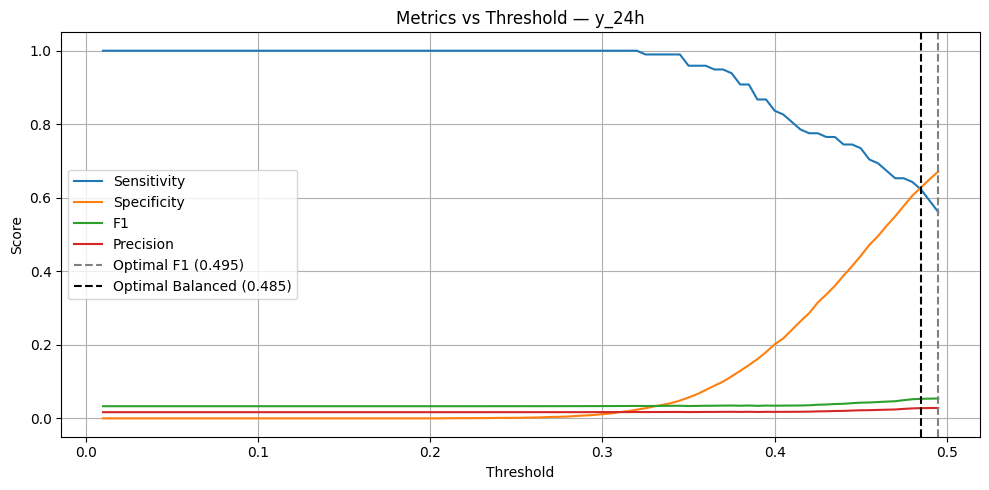

In [46]:
def plot_threshold_curve(y_true, y_prob, target_label='y_24h'):
    thresholds = np.arange(0.01, 0.5, 0.005)
    sens_list, spec_list, f1_list, prec_list = [], [], [], []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sens_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        spec_list.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        prec_list.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
        f1_list.append(f1_score(y_true, y_pred, zero_division=0))

    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, sens_list,  label='Sensitivity')
    plt.plot(thresholds, spec_list,  label='Specificity')
    plt.plot(thresholds, f1_list,    label='F1')
    plt.plot(thresholds, prec_list,  label='Precision')
    plt.axvline(t_f1,  color='gray',  linestyle='--', label=f'Optimal F1 ({t_f1:.3f})')
    plt.axvline(t_bal, color='black', linestyle='--', label=f'Optimal Balanced ({t_bal:.3f})')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title(f'Metrics vs Threshold — {target_label}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_threshold_curve(y_test, y_prob, target_label='y_24h')

##12) Compare logistic qSOFA across all horizons

In [48]:
logreg_results = {}

for target_label, eligible_col in [
    ('y_6h', 'eligible_6h'),
    ('y_12h', 'eligible_12h'),
    ('y_24h', 'eligible_24h'),
]:
    print('\n' + '=' * 70)
    print(f'Logistic qSOFA model for {target_label}')
    print('=' * 70)

    res = train_qsofa_logistic_model(
        qsofa_dataset,
        split_df,
        target_label=target_label,
        eligible_col=eligible_col
    )

    logreg_results[target_label] = res  # store full result, not just AUROC/AUPRC


Logistic qSOFA model for y_6h
Target: y_6h
Eligible stays: 64,815
Positive rate : 0.0046
Train: 39,226 | positives: 207 | rate: 0.0053
Val  : 8,418 | positives: 45 | rate: 0.0053
Test : 8,428 | positives: 35 | rate: 0.0042

Validation AUROC: 0.4678
Validation AUPRC: 0.0053
Test AUROC      : 0.5646
Test AUPRC      : 0.0050

Classification Report (threshold = 0.5)
              precision    recall  f1-score   support

           0     0.9967    0.6211    0.7653      8393
           1     0.0056    0.5143    0.0111        35

    accuracy                         0.6207      8428
   macro avg     0.5012    0.5677    0.3882      8428
weighted avg     0.9926    0.6207    0.7622      8428

Confusion Matrix:
TN=5213  FP=3180
FN=17  TP=18
Sensitivity: 0.5143
Specificity: 0.6211
Precision  : 0.0056
NPV        : 0.9967

Logistic qSOFA model for y_12h
Target: y_12h
Eligible stays: 58,021
Positive rate : 0.0078
Train: 34,879 | positives: 318 | rate: 0.0091
Val  : 7,484 | positives: 66 | rate: 0.00

In [49]:
print('\nSummary of logistic qSOFA model:')
for h, r in logreg_results.items():
    print(
        f'{h:6s} | '
        f'Val AUROC={r["val_auroc"]:.4f} | '
        f'Val AUPRC={r["val_auprc"]:.4f} | '
        f'Test AUROC={r["test_auroc"]:.4f} | '
        f'Test AUPRC={r["test_auprc"]:.4f}'
    )


Summary of logistic qSOFA model:
y_6h   | Val AUROC=0.4678 | Val AUPRC=0.0053 | Test AUROC=0.5646 | Test AUPRC=0.0050
y_12h  | Val AUROC=0.5104 | Val AUPRC=0.0104 | Test AUROC=0.5800 | Test AUPRC=0.0129
y_24h  | Val AUROC=0.5215 | Val AUPRC=0.0242 | Test AUROC=0.6317 | Test AUPRC=0.0339


In [50]:
print('\nOptimal threshold evaluation across all horizons:')
for target_label, res in logreg_results.items():
    y_true = res['y_test']
    y_prob = res['y_prob_test']

    t_f1,  _ = find_optimal_threshold(y_true, y_prob, metric='f1')
    t_bal, _ = find_optimal_threshold(y_true, y_prob, metric='balanced')

    print(f'\n{target_label}')
    evaluate_at_threshold(y_true, y_prob, 0.5,   label='(default)')
    evaluate_at_threshold(y_true, y_prob, t_f1,  label='(optimal F1)')
    evaluate_at_threshold(y_true, y_prob, t_bal, label='(optimal balanced)')


Optimal threshold evaluation across all horizons:

y_6h

Threshold = 0.500  (default)
Sensitivity : 0.5143
Specificity : 0.6211
Precision   : 0.0056
NPV         : 0.9967
F1          : 0.0111
TN=5213  FP=3180  FN=17  TP=18

Threshold = 0.495  (optimal F1)
Sensitivity : 0.5143
Specificity : 0.6006
Precision   : 0.0053
NPV         : 0.9966
F1          : 0.0106
TN=5041  FP=3352  FN=17  TP=18

Threshold = 0.470  (optimal balanced)
Sensitivity : 0.6286
Specificity : 0.4947
Precision   : 0.0052
NPV         : 0.9969
F1          : 0.0102
TN=4152  FP=4241  FN=13  TP=22

y_12h

Threshold = 0.500  (default)
Sensitivity : 0.4655
Specificity : 0.6485
Precision   : 0.0102
NPV         : 0.9936
F1          : 0.0201
TN=4811  FP=2608  FN=31  TP=27

Threshold = 0.485  (optimal F1)
Sensitivity : 0.5345
Specificity : 0.5858
Precision   : 0.0100
NPV         : 0.9938
F1          : 0.0196
TN=4346  FP=3073  FN=27  TP=31

Threshold = 0.485  (optimal balanced)
Sensitivity : 0.5345
Specificity : 0.5858
Precision 

##13) Plot ROC and PR curves for the logistic model

In [51]:
def plot_qsofa_logistic_curves(y_test, y_prob, target_label='y_24h'):
    auroc = roc_auc_score(y_test, y_prob)
    auprc = average_precision_score(y_test, y_prob)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, lw=2, label=f'AUROC = {auroc:.3f}')
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title(f'ROC Curve — {target_label}')
    axes[0].legend()
    axes[0].grid(True)

    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    baseline = y_test.mean()
    axes[1].plot(rec, prec, lw=2, label=f'AUPRC = {auprc:.3f}')
    axes[1].axhline(y=baseline, color='k', linestyle='--', lw=1, label=f'Baseline = {baseline:.3f}')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'PR Curve — {target_label}')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

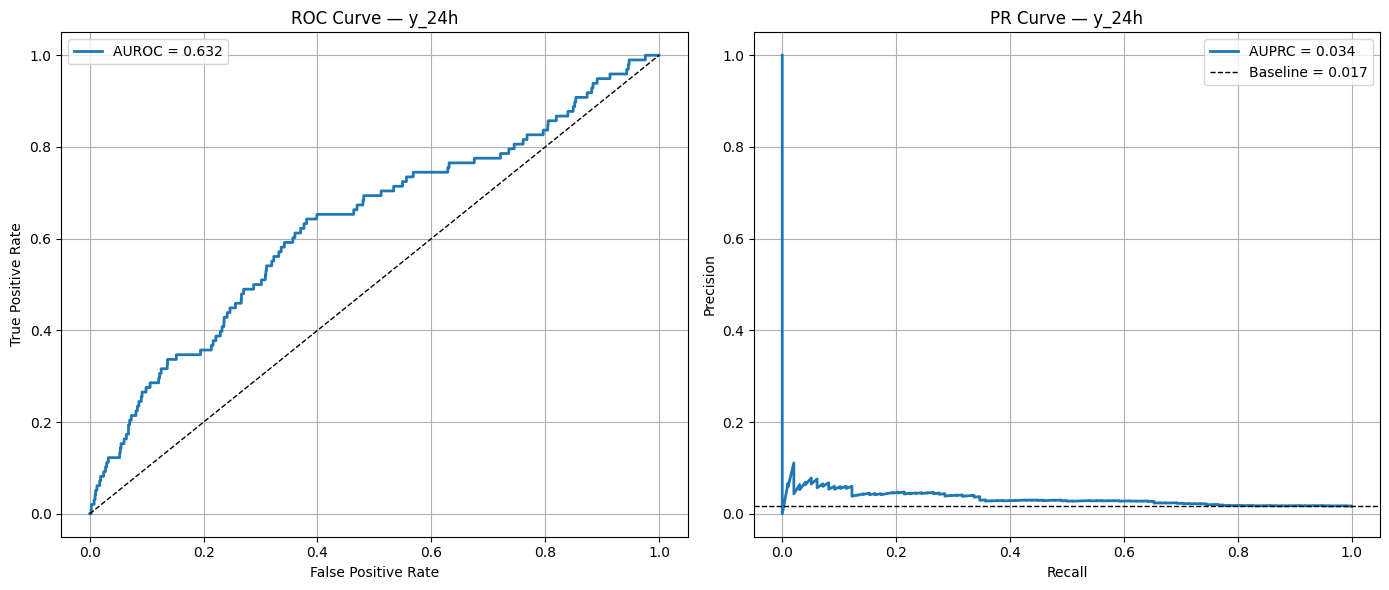

In [52]:
plot_qsofa_logistic_curves(
    logreg_24h['y_test'],
    logreg_24h['y_prob_test'],
    target_label='y_24h'
)

##14) Inspect which qSOFA features mattered most

In [40]:
coef_df = pd.DataFrame({
    'feature': logreg_24h['feature_cols'],
    'coefficient': logreg_24h['model'].coef_[0]
}).sort_values('coefficient', key=np.abs, ascending=False)

coef_df

,feature,coefficient
1,qsofa_std_24h,-0.317154
11,gcs_qsofa_hours,0.261481
6,qsofa_slope_24h,0.207849
5,qsofa_last_24h,-0.169455
4,qsofa_first_24h,0.142342
8,qsofa_any_ge2,0.132482
0,qsofa_mean_24h,0.132179
10,sbp_qsofa_hours,-0.086223
2,qsofa_min_24h,-0.079597
3,qsofa_max_24h,0.035764


#What we now have

we now have two medically sensible models from scratch:

##Model 1 — Pure clinical baseline
uses qSOFA >= 2
easy to explain to instructor
clinically interpretable
medically applicable
##Model 2 — Interpretable ML baseline
logistic regression using qSOFA-derived features
still explainable
usually stronger than fixed bedside rule
more convincing academically